In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

df = pd.read_csv('../data/Advertising.csv')
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [3]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


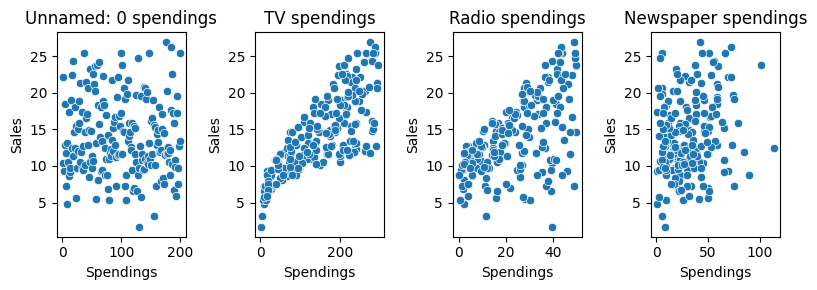

In [4]:
number_features = df.shape[1] - 1
fig, ax = plt.subplots(1, number_features, figsize=(8, 3), dpi=100)

for i, feature in enumerate(df.columns[:-1]):
    sns.scatterplot(data=df, x=feature, y="Sales", ax=ax[i])
    ax[i].set(xlabel="Spendings", title=f"{feature} spendings")

fig.tight_layout()

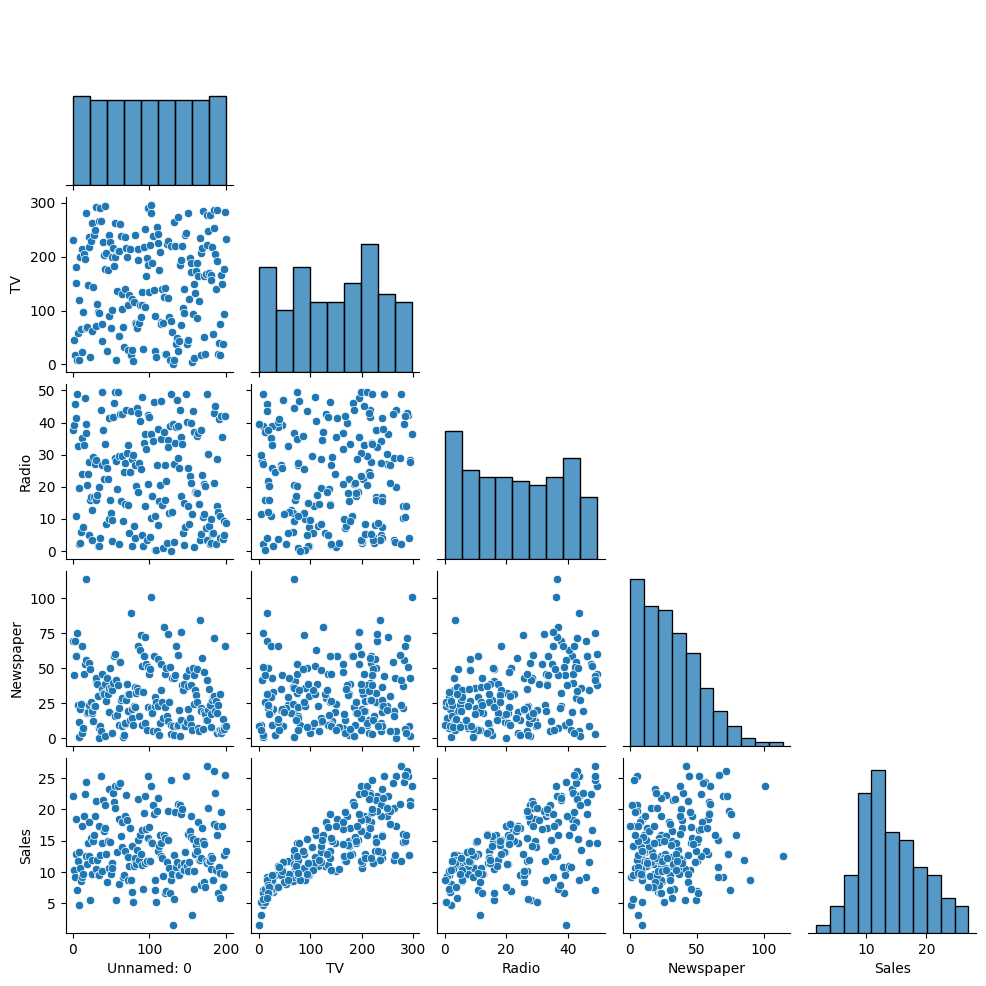

In [5]:
ax = sns.pairplot(df, corner=True, height=2)

Intercept (beta_0): 7.0326
Intercept (beta_1): 0.0475


[Text(0.5, 1.0, 'TV advertisement linear regression'),
 Text(0.5, 0, 'Thousand dollars'),
 Text(0, 0.5, 'Sales thousand units')]

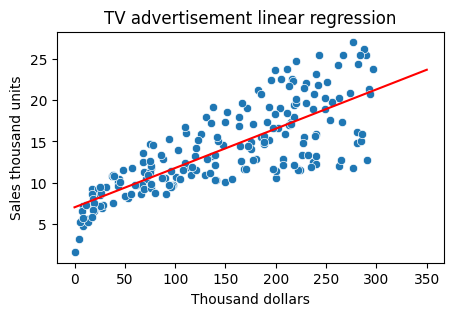

In [6]:
X, y = df["TV"], df["Sales"]

beta_1, beta_0 = np.polyfit(X, y, deg=1)

y_hat = lambda x: beta_0 + beta_1 * x

print(f"Intercept (beta_0): {beta_0:.4f}")
print(f"Intercept (beta_1): {beta_1:.4f}")

spend = np.linspace(0, 350)
fig, ax = plt.figure(figsize=(5, 3), dpi=100), plt.axes()

sns.scatterplot(data=df, x="TV", y="Sales")
sns.lineplot(x=spend, y=y_hat(spend), color="red")

ax.set(title="TV advertisement linear regression",
        xlabel="Thousand dollars",
        ylabel="Sales thousand units")

<Axes: xlabel='TV', ylabel='Sales'>

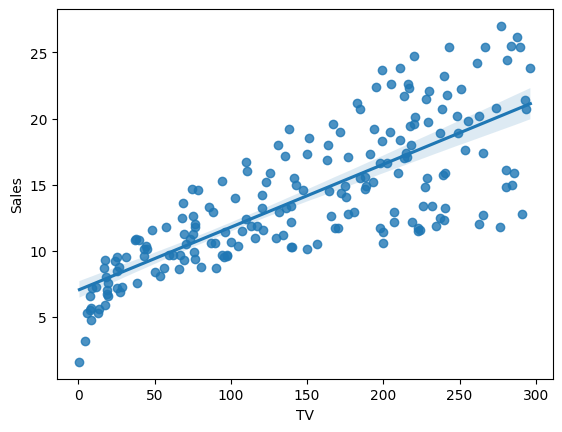

In [7]:
sns.regplot(x=X, y=y)

In [8]:
X, y = df.drop("Sales", axis="columns"), df["Sales"]

model = LinearRegression()
beta = model.fit(X, y)

beta.score(X, y)

test_sample = [[1, 230.1, 37.8, 69.2]]
y_hat = model.predict(test_sample)

print(f"TV: 230.1k, Radio: 37.8k, Newspaper: 69.2k predicts {y_hat[0]:.1f}k units")


TV: 230.1k, Radio: 37.8k, Newspaper: 69.2k predicts 20.6k units


/home/alex/iths/Machine-learning-AI24/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [9]:
train_fraction = int(len(df) * 0.7)

train = df.sample(n=train_fraction, random_state=42, replace=False)
val = df.drop(train.index)

X_train, y_train = train.drop("Sales", axis="columns"), train["Sales"]
X_val, y_val = val.drop("Sales", axis="columns"), val["Sales"]

X_train.insert(0, "Intercept", 1)
X_val.insert(0, "Intercept", 1)

for dataset in ["X_train", "X_val", "y_train", "y_val"]:
    print(f"Shape of {dataset}: {eval(dataset).shape}")

Shape of X_train: (140, 5)
Shape of X_val: (60, 5)
Shape of y_train: (140,)
Shape of y_val: (60,)


In [10]:
model = LinearRegression()
model.fit(X_train, y_train)



LinearRegression()

lägg till formeln för MAE här

In [14]:
n = len(y_val)
y_hat = model.predict(X_val)

MAE = np.divide(1, n) * np.sum(np.abs(y_val - y_hat))
MSE = np.divide(1, n) * np.sum(np.square(y_val - y_hat))
RMSE = np.sqrt(MSE)
RSE = np.sqrt(np.divide(1, n - X_val.shape[1] -2) * np.sum(np.square(y_val - y_hat)))

MAE, MSE, RMSE, RSE

(np.float64(1.3242128694611697),
 np.float64(3.5468899866282664),
 np.float64(1.8833188754505346),
 np.float64(2.0038331154748166))